In [ ]:
import plotly.express as px
import requests
import pandas as pd
import os


# 1. Fetch municipality GeoJSON from DAWA
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# Each feature has properties: "kode" (4-digit code), "navn" (name)
# Extract names and codes for a base dataframe
municipalities = [
    {
        "Municipality" : f["properties"]["navn"],
        "KommuneCode"  : f["properties"]["kode"],
        "RegionName"   : f["properties"]["regionsnavn"],
        "RegionCode"   : f["properties"]["regionskode"]
    }
    for f in geojson["features"]
]
df_mun = pd.DataFrame(municipalities)

os.makedirs("../data/geography", exist_ok=True)
df_mun.to_csv("../data/geography/municipalities.csv", encoding="utf-8", index=False)


,Municipality,KommuneCode,RegionName,RegionCode
0,København,0101,Region Hovedstaden,1084
1,Frederiksberg,0147,Region Hovedstaden,1084
2,Ballerup,0151,Region Hovedstaden,1084
3,Brøndby,0153,Region Hovedstaden,1084
4,Dragør,0155,Region Hovedstaden,1084


In [ ]:
df_mun = pd.read_csv("../data/geography/municipalities.csv", encoding="utf-8")

In [12]:
#geojson.keys() # ['type', 'crs', 'features']
geojson_data = geojson['features']
#geojson_data[0].keys() # ['type', 'geometry', 'properties', 'bbox']
geojson_data[0]['properties'] # dict_keys(['kod', 'navn', 'regionskode', 'regionsnavn'])
for region in geojson['features']:
    pass
    #print(region['properties']['kode'], region['properties']['navn']) # ,"//", region['properties']['regionskode'], region['properties']['regionsnavn'])

In [ ]:
# 2. (Optional) Merge your own data — e.g. employee counts
# df = df.merge(your_df, on="navn", how="left")
# For demo, just use a dummy value
df["value"] = 1

# 3. Plot
fig = px.choropleth_map(
    df,
    geojson=geojson,
    locations="regionskode",                          # column in df to match GeoJSON
    featureidkey="properties.regionskode",            # key inside GeoJSON features
    color="value",                             # column to color by
    hover_name="navn",
    # map_style="carto-positron",
    center={"lat": 56.0, "lon": 10.5},
    zoom=5.5,
    opacity=0.6,
    color_continuous_scale="Blues",
    range_color=(0.5, 1.5),
    title="Danish Municipalities"
)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

In [25]:
df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

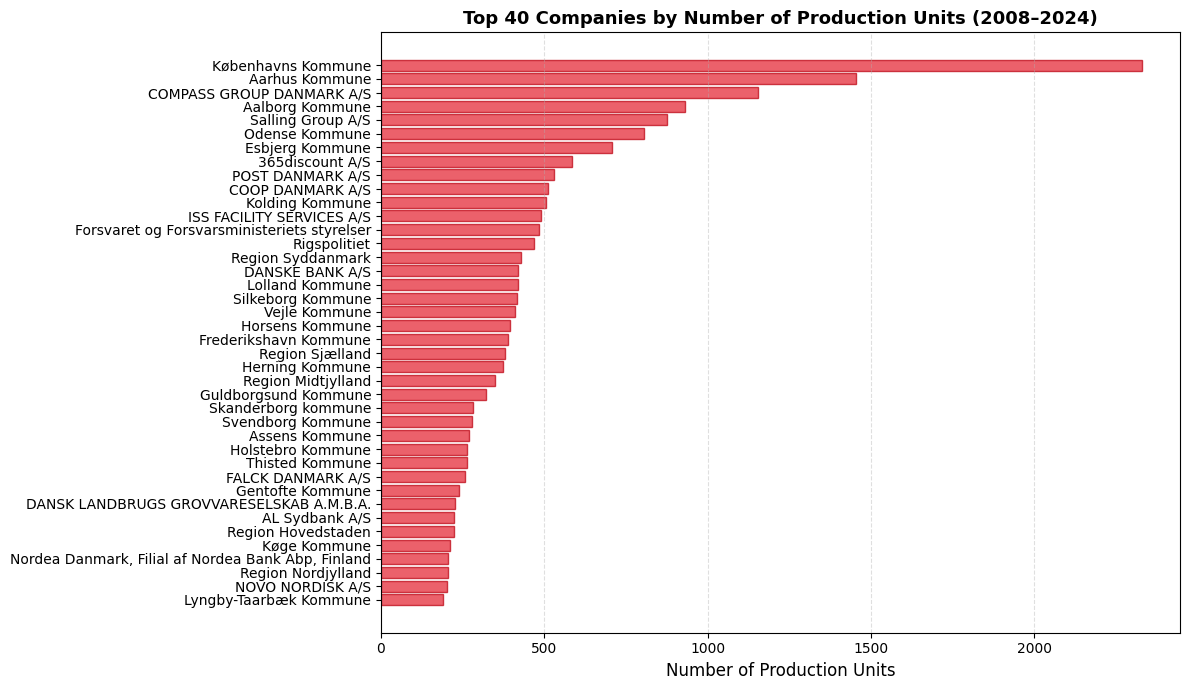

Total companies:                154
Companies with only 1 unit:     24
Companies with 2–5 units:       22
Companies with 6–20 units:      27
Companies with >20 units:       81

Top 10 companies:
              CompanyName  UnitCount
       Københavns Kommune       2329
           Aarhus Kommune       1455
COMPASS GROUP DANMARK A/S       1154
          Aalborg Kommune        930
        Salling Group A/S        877
           Odense Kommune        805
          Esbjerg Kommune        707
          365discount A/S        584
         POST DANMARK A/S        530
         COOP DANMARK A/S        511


In [29]:
import matplotlib.pyplot as plt

# Count production units per company
company_counts = (
    df_plot.groupby('CompanyName')
    .size()
    .reset_index(name='UnitCount')
    .sort_values('UnitCount', ascending=False)
)

# ── Plot top N companies ──────────────────────────────────────────────────────
top_n = 40
df_top = company_counts.head(top_n)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(df_top['CompanyName'][::-1], df_top['UnitCount'][::-1], color='#e63946', edgecolor='#c1121f', alpha=0.8)
ax.set_xlabel('Number of Production Units', fontsize=12)
ax.set_title(f'Top {top_n} Companies by Number of Production Units (2008–2024)', fontsize=13, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('company_unit_distribution.png', dpi=150)
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print(f"Total companies:                {len(company_counts)}")
print(f"Companies with only 1 unit:     {(company_counts['UnitCount'] == 1).sum()}")
print(f"Companies with 2–5 units:       {company_counts['UnitCount'].between(2, 5).sum()}")
print(f"Companies with 6–20 units:      {company_counts['UnitCount'].between(6, 20).sum()}")
print(f"Companies with >20 units:       {(company_counts['UnitCount'] > 20).sum()}")
print(f"\nTop 10 companies:")
print(company_counts.head(10).to_string(index=False))

In [ ]:
import folium
import requests

# 1. Fetch GeoJSON
geojson = requests.get(
    "https://api.dataforsyningen.dk/kommuner?format=geojson"
).json()

# 2. Create base map centered on Denmark
m = folium.Map(
    location=[56.0, 10.5],
    zoom_start=7,
    tiles="CartoDB positron"
)

# 3. Add municipality boundaries with popups
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function=lambda feature: {
        "fillColor": "#4a90d9",
        "color": "#1a1a2e",
        "weight": 1,
        "fillOpacity": 0.4,
    },
    highlight_function=lambda feature: {
        "fillColor": "#f0a500",
        "fillOpacity": 0.7,
        "weight": 2,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["navn", "kode", "regionsnavn"],
        aliases=["Municipality:", "Code:", "Region:"],
        localize=True,
    ),
).add_to(m)

folium.LayerControl().add_to(m)
m.save("municipalities.html")   # open in browser
#m                                # renders inline in Jupyter

In [15]:
# Region colour palette
region_colors = {
    "Region Hovedstaden" : "#e63946",
    "Region Midtjylland" : "#2a9d8f",
    "Region Syddanmark"  : "#e9c46a",
    "Region Nordjylland" : "#457b9d",
    "Region Sjælland"    : "#8338ec",
}

def style_function(feature):
    region = feature["properties"].get("regionsnavn", "")
    return {
        "fillColor"  : region_colors.get(region, "#cccccc"),
        "color"      : "#1a1a2e",
        "weight"     : 1,
        "fillOpacity": 0.4,
    }

def highlight_function(feature):
    region = feature["properties"].get("regionsnavn", "")
    return {
        "fillColor"  : region_colors.get(region, "#aaaaaa"),
        "fillOpacity": 0.7,
        "weight"     : 2,
    }

# Base map
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")

# Municipality boundaries coloured by region
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function    = style_function,
    highlight_function= highlight_function,
    tooltip=folium.GeoJsonTooltip(
        fields=  ["navn",          "kode",    "regionsnavn"],
        aliases= ["Municipality:", "Code:",   "Region:"],
        localize=True,
    ),
).add_to(m)

# ── Region legend ─────────────────────────────────────────────────────────────
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
            background: white; padding: 12px 16px; border-radius: 8px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.3); font-family: sans-serif; font-size: 13px;">
  <b>Region</b><br>
""" + "".join([
    f'<span style="display:inline-block;width:14px;height:14px;'
    f'background:{color};border-radius:50%;margin-right:6px;vertical-align:middle;"></span>'
    f'{region}<br>'
    for region, color in region_colors.items()
]) + "</div>"

m.get_root().html.add_child(folium.Element(legend_html))

save_name = "regions_municipalities.html"
m.save(save_name)
print(f"Saved → {save_name}")

Saved → regions_municipalities.html


In [22]:
from folium.plugins import TimestampedGeoJson

df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

df_plot['UnitEnddate'] = pd.to_datetime(df_plot['UnitEnddate'], errors='coerce')
df_plot['UnitStartdate'] = pd.to_datetime(
    df_plot['UnitStartdate'].str.replace(' - ', '/', regex=False),
    format='%d/%m/%Y',
    errors='coerce'
)

current_year = 2024

df_plot['StartYear'] = (
    df_plot['UnitStartdate'].dt.year
    .fillna(2008)
    .astype(int)
    .clip(lower=2008)
)

df_plot['EndYear'] = (
    df_plot['UnitEnddate'].dt.year
    .fillna(current_year)
    .astype(int)
)
# ── 2. Build GeoJSON features — one entry per (unit × active year) ────────────
# TimestampedGeoJson needs each feature to carry a 'times' list with one
# timestamp per "frame" the feature should appear in.

# Base map
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")


features = []

for _, row in df_plot.iterrows():
    active_years = list(range(int(row['StartYear']), int(row['EndYear']) + 1))
    times        = [f"{yr}-01-01" for yr in active_years]   # ISO date per year

    feature = {
        "type": "Feature",
        "geometry": {
            "type"       : "Point",
            "coordinates": [row['Lon'], row['Lat']]          # GeoJSON is [lon, lat]
        },
        "properties": {
            "times"  : times,
            "popup"  : (
                f"<b>{row['UnitName']}</b><br>"
                f"<b>Company:</b> {row['CompanyName']}<br>"
                f"<b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>"
                f"<b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>"
                f"<b>Region:</b> {row['RegionName']}<br>"
                f"<b>Employees:</b> {row['UnitEmployees']}<br>"
                f"<b>Active:</b> {int(row['StartYear'])} – "
                f"{'Open' if pd.isna(row['UnitEnddate']) else int(row['EndYear'])}"
            ),
            "icon"   : "circle",
            "iconstyle": {
                "fillColor"  : "#e63946",
                "fillOpacity": 0.3,
                "stroke"     : True,
                "color"      : "#c1121f",
                "weight"     : 1,
                "radius"     : 1.3,
            }
        }
    }
    features.append(feature)

# ── 3. Add TimestampedGeoJson to map ─────────────────────────────────────────
TimestampedGeoJson(
    data           = {"type": "FeatureCollection", "features": features},
    period         = "P1Y",
    duration       = "P1Y",
    auto_play      = False,
    loop           = False,
    max_speed      = 1,          # slowest speed multiplier
    loop_button    = True,
    date_options   = "YYYY",
    time_slider_drag_update = True,
    transition_time = 800,      # ← ms between frames (2000 = 2 seconds per year)
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m.save("municipalities_animated.html")
print("Saved → municipalities_animated.html")

Saved → municipalities_animated.html


In [24]:
company_geojsons = {}
all_companies    = sorted(df_plot['CompanyName'].dropna().unique().tolist())

for company in all_companies:
    df_company = df_plot[df_plot['CompanyName'] == company]
    feats      = []
    for _, row in df_company.iterrows():
        active_years = list(range(int(row['StartYear']), int(row['EndYear']) + 1))
        times        = [f"{yr}-01-01T00:00:00" for yr in active_years]
        feats.append({
            "type"    : "Feature",
            "geometry": {"type": "Point", "coordinates": [row['Lon'], row['Lat']]},
            "properties": {
                "times"   : times,
                "popup"   : (
                    f"<b>{row['UnitName']}</b><br>"
                    f"<b>Company:</b> {row['CompanyName']}<br>"
                    f"<b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>"
                    f"<b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>"
                    f"<b>Region:</b> {row['RegionName']}<br>"
                    f"<b>Employees:</b> {row['UnitEmployees']}<br>"
                    f"<b>Active:</b> {int(row['StartYear'])} – "
                    f"{'Open' if pd.isna(row['UnitEnddate']) else int(row['EndYear'])}"
                ),
            }
        })
    company_geojsons[company] = {"type": "FeatureCollection", "features": feats}

# "All" option
all_features = []
for feats in company_geojsons.values():
    all_features.extend(feats["features"])
company_geojsons["— All Companies —"] = {"type": "FeatureCollection", "features": all_features}
all_companies = ["— All Companies —"] + all_companies

# ── 2. Build base Folium map (NO TimestampedGeoJson plugin) ──────────────────
m = folium.Map(location=[56.0, 10.5], zoom_start=7, tiles="CartoDB positron")

# Municipality boundaries
folium.GeoJson(
    geojson,
    name="Municipalities",
    style_function    = style_function,
    highlight_function= highlight_function,
    tooltip=folium.GeoJsonTooltip(
        fields=  ["navn", "kode", "regionsnavn"],
        aliases= ["Municipality:", "Code:", "Region:"],
        localize=True,
    ),
).add_to(m)

map_name = m.get_name()

# ── 3. Inject TimeDimension manually + dropdown ───────────────────────────────
companies_js     = json.dumps(company_geojsons, ensure_ascii=False)
dropdown_options = "\n".join(
    [f'<option value="{c}">{c}</option>' for c in all_companies]
)

custom_html = f"""
<!-- TimeDimension CSS & JS -->
<link rel="stylesheet"
      href="https://cdnjs.cloudflare.com/ajax/libs/leaflet-timedimension/1.1.1/leaflet.timedimension.control.min.css"/>
<script src="https://cdnjs.cloudflare.com/ajax/libs/leaflet-timedimension/1.1.1/leaflet.timedimension.min.js"></script>

<!-- Company filter dropdown -->
<div id="company-filter" style="position:fixed; top:80px; right:10px; z-index:9999;
     background:white; padding:12px 16px; border-radius:8px;
     box-shadow:0 2px 8px rgba(0,0,0,0.3); font-family:sans-serif;
     font-size:13px; max-width:280px;">
    <b>Filter by Company</b><br><br>
    <input id="companySearch" type="text" placeholder="Search company..."
           oninput="filterDropdown(this.value)"
           style="width:100%; padding:6px; border-radius:4px;
                  border:1px solid #ccc; font-size:12px; margin-bottom:6px; box-sizing:border-box;"/>
    <select id="companySelect" size="8" onchange="updateLayer(this.value)"
            style="width:100%; padding:4px; border-radius:4px;
                   border:1px solid #ccc; font-size:12px;">
        {dropdown_options}
    </select>
</div>

<script>
var allCompanyData  = {companies_js};
var allOptions      = Array.from(document.getElementById("companySelect").options).map(o => o.value);
var currentTDLayer  = null;
var timeDimension   = null;
var tdControl       = null;
var mapObj          = null;

// ── Filter dropdown by search input ──────────────────────────────────────────
function filterDropdown(query) {{
    var sel      = document.getElementById("companySelect");
    var filtered = allOptions.filter(o => o.toLowerCase().includes(query.toLowerCase()));
    sel.innerHTML = filtered.map(o => `<option value="${{o}}">${{o}}</option>`).join("");
}}

// ── Swap TimeDimension layer on company selection ─────────────────────────────
function updateLayer(companyName) {{
    if (!companyName) return;

    var geojsonData = allCompanyData[companyName];
    if (!geojsonData) return;

    // Remove existing TD layer
    if (currentTDLayer) {{
        mapObj.removeLayer(currentTDLayer);
        currentTDLayer = null;
    }}

    // Remove existing TD control
    if (tdControl) {{
        mapObj.removeControl(tdControl);
        tdControl = null;
    }}

    // Remove existing timeDimension
    if (mapObj.timeDimension) {{
        delete mapObj.timeDimension;
    }}

    // Collect all unique timestamps from this company's features
    var times = [];
    geojsonData.features.forEach(function(f) {{
        (f.properties.times || []).forEach(function(t) {{
            if (!times.includes(t)) times.push(t);
        }});
    }});
    times.sort();

    if (times.length === 0) return;

    // Create new TimeDimension with this company's time range
    mapObj.timeDimension = L.timeDimension({{
        times          : times,
        currentTime    : new Date(times[0]).getTime(),
    }});

    // Add TD control (slider)
    tdControl = L.control.timeDimension({{
        player: {{
            transitionTime : 1500,
            loop           : false,
            startOver      : true,
        }},
        timeZones          : ["Local"],
        autoPlay           : false,
        loopButton         : true,
        timeSliderDragUpdate: true,
        speedSlider        : false,
        playerOptions      : {{ buttonType: "play" }},
    }});
    tdControl.addTo(mapObj);

    // Build GeoJSON layer with circle markers
    var geoLayer = L.geoJson(geojsonData, {{
        pointToLayer: function(feature, latlng) {{
            return L.circleMarker(latlng, {{
                radius      : 2,
                fillColor   : "#e63946",
                color       : "#c1121f",
                weight      : 1,
                fillOpacity : 0.3,
            }});
        }},
        onEachFeature: function(feature, layer) {{
            if (feature.properties.popup) {{
                layer.bindPopup(feature.properties.popup);
            }}
        }}
    }});

    // Wrap in TimeDimension GeoJSON layer
    currentTDLayer = L.timeDimension.layer.geoJson(geoLayer, {{
        updateTimeDimension         : false,
        waitForReady                : true,
        updateTimeDimensionMode     : "replace",
        addlastPoint                : false,
        duration                    : "P1Y",
    }});

    currentTDLayer.addTo(mapObj);
}}

// ── Init after DOM ready ──────────────────────────────────────────────────────
document.addEventListener("DOMContentLoaded", function() {{
    mapObj = window["{map_name}"];

    // Small delay to ensure Leaflet is fully initialised
    setTimeout(function() {{
        var sel = document.getElementById("companySelect");
        sel.value = "— All Companies —";
        updateLayer("— All Companies —");
    }}, 500);
}});
</script>
"""

m.get_root().html.add_child(folium.Element(custom_html))
save_name = "JS_municipalities_animated.html"
m.save(save_name)
print(f"Saved → {save_name}")

Saved → JS_municipalities_animated.html


In [ ]:
from folium.plugins import MarkerCluster

df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()


region_groups   = {}
region_clusters = {}

for kommune in sorted(df_plot['KommuneName'].dropna().unique()):
    group   = folium.FeatureGroup(name=f"📍 {kommune}", show=True)
    cluster = MarkerCluster(options={"maxClusterRadius": 40})
    cluster.add_to(group)
    region_groups[kommune]   = group
    region_clusters[kommune] = cluster

no_region_group   = folium.FeatureGroup(name="📍 Kommune Unknown", show=True)
no_region_cluster = MarkerCluster(options={"maxClusterRadius": 40})
no_region_cluster.add_to(no_region_group)

for _, row in df_plot.iterrows():
    popup_html = f"""
        <b>{row['UnitName']}</b><br>
        <b>Company:</b> {row['CompanyName']}<br>
        <b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>
        <b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>
        <b>Region:</b> {row['RegionName']} ({row['RegionCode']})<br>
        <b>Employees:</b> {row['UnitEmployees']}<br>
        <b>Start:</b> {row['UnitStartdate']}<br>
        <b>End:</b> {row['UnitEnddate'] if pd.notna(row['UnitEnddate']) else 'Active'}
    """
    marker = folium.CircleMarker(
        location     = [row['Lat'], row['Lon']],
        radius       = 5,
        color        = "#e63946",
        fill         = True,
        fill_color   = "#e63946",
        fill_opacity = 0.7,
        popup        = folium.Popup(popup_html, max_width=300),
        tooltip      = row['UnitName']
    )

    kommune = row['KommuneName']
    if pd.notna(kommune) and kommune in region_clusters:
        marker.add_to(region_clusters[kommune])
    else:
        marker.add_to(no_region_cluster)

for group in region_groups.values():
    group.add_to(m)
no_region_group.add_to(m)

In [ ]:
df_pUnit = pd.read_csv('../data/CVR_API/cvr_production_units_geocoded.csv', encoding='utf-8')
df_plot = df_pUnit.dropna(subset=['Lat', 'Lon']).copy()

region_groups = {}
for region in sorted(df_plot['KommuneName'].dropna().unique()):
    group = folium.FeatureGroup(name=f"{region}", show=True)
    region_groups[region] = group

# Catch-all group for units with no region resolved
no_region_group = folium.FeatureGroup(name="Region Unknown", show=True)

for _, row in df_plot.iterrows():
    popup_html = f"""
        <b>{row['UnitName']}</b><br>
        <b>Company:</b> {row['CompanyName']}<br>
        <b>Address:</b> {row['UnitAddress']}, {row['UnitZipcode']} {row['UnitCity']}<br>
        <b>Kommune:</b> {row['KommuneName']} ({row['KommuneCode']})<br>
        <b>Region:</b> {row['RegionName']} ({row['RegionCode']})<br>
        <b>Employees:</b> {row['UnitEmployees']}<br>
        <b>Start:</b> {row['UnitStartdate']}<br>
        <b>End:</b> {row['UnitEnddate'] if pd.notna(row['UnitEnddate']) else 'Active'}
    """
    marker = folium.CircleMarker(
        location   = [row['Lat'], row['Lon']],
        radius     = 6,
        color      = "#e63946",
        fill       = True,
        fill_color = "#e63946",
        fill_opacity = 0.7,
        popup      = folium.Popup(popup_html, max_width=300),
        tooltip    = row['UnitName']
    )

    region = row['KommuneName']
    if pd.notna(region) and region in region_groups:
        marker.add_to(region_groups[region])
    else:
        marker.add_to(no_region_group)

# Add all groups to map
for group in region_groups.values():
    group.add_to(m)
no_region_group.add_to(m)

# 6. Layer control (enables show/hide per region)
folium.LayerControl(collapsed=False).add_to(m)

save_name = "companies_markers.html"
m.save(save_name)
print(f"Saved → {save_name}")
